In [470]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [471]:
model_df = pd.read_csv(
    "D:/clg_project/AI-Financial-Wellness-Coach/data/processed/expense_features.csv"
)

print(model_df.shape)

(7000, 7)


## Data Validation

In [472]:
model_df.head(5)

,transaction_text,amount,amount_log,amount_bucket,payment_method,transaction_type,category
0,Credit Card Bill Payment Auto Debit Credit Car...,4361.84,8.380879,Large,Auto Debit,Debit,Bills
1,Zepto UPI/Paytm/Zepto,1226.03,7.112352,Medium,Upi,Debit,Groceries
2,Ace Hardware India POS Purchase Ace Hardware I...,523.73,6.262884,Small,Credit Card,Debit,Miscellaneous
3,Zepto UPI/DR/623175732898/Zepto,1290.29,7.163397,Medium,Upi,Debit,Groceries
4,House Rent Payment NEFT Rent Payment,44800.94,10.710007,Large,Neft,Debit,Rent


In [473]:


print("\nMissing values:")
print(model_df.isnull().sum())




Missing values:
transaction_text    0
amount              0
amount_log          0
amount_bucket       0
payment_method      0
transaction_type    0
category            0
dtype: int64


In [474]:
print("\nData types:")
print(model_df.dtypes)


Data types:
transaction_text     object
amount              float64
amount_log          float64
amount_bucket        object
payment_method       object
transaction_type     object
category             object
dtype: object


In [475]:

print("\nDuplicate rows:")
print(model_df.duplicated().sum())


Duplicate rows:
222


In [476]:
print("\nUnique transaction texts:")
print(model_df["transaction_text"].nunique())


Unique transaction texts:
1209


In [477]:

print("\nEmpty transaction texts:")
print(
    (model_df["transaction_text"].astype(str).str.strip() == "").sum()
)


Empty transaction texts:
0


In [478]:
model_df.category.unique()

array(['Bills', 'Groceries', 'Miscellaneous', 'Rent', 'Food',
       'Entertainment', 'Shopping', 'Fuel', 'Subscription', 'Salary',
       'Insurance', 'Other', 'Investment'], dtype=object)

In [479]:
category_distribution = (
    model_df["category"]
    .value_counts()
    .to_frame("count")
)

category_distribution["percentage"] = (
    category_distribution["count"]
    / len(model_df)
    * 100
).round(2)

print(category_distribution)

               count  percentage
category                        
Bills           2059       29.41
Food            1328       18.97
Groceries        912       13.03
Shopping         550        7.86
Other            435        6.21
Fuel             423        6.04
Miscellaneous    358        5.11
Subscription     242        3.46
Salary           173        2.47
Entertainment    167        2.39
Rent             165        2.36
Insurance        152        2.17
Investment        36        0.51


## EDA

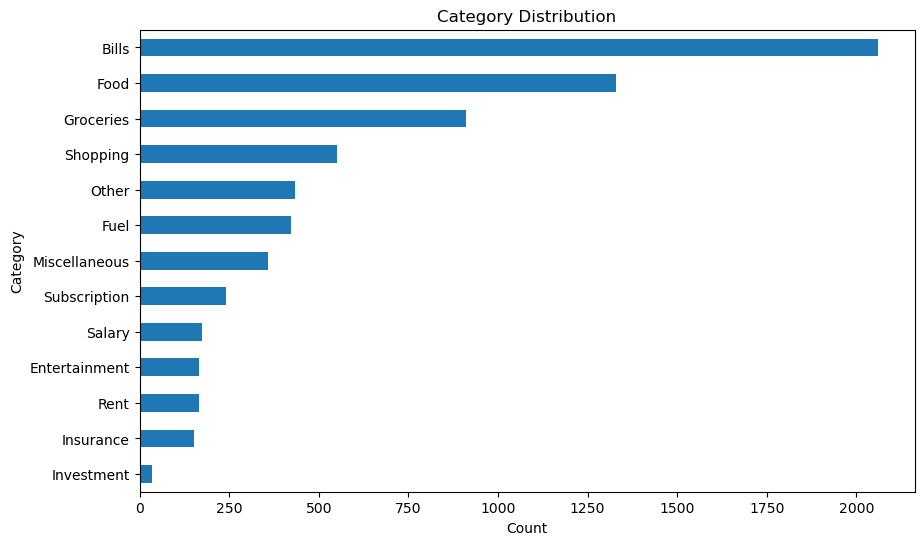

In [480]:
# Category distribution plot

model_df['category'].value_counts().sort_values().plot(kind='barh', figsize=(10, 6))

plt.title('Category Distribution')
plt.xlabel('Count')  
plt.ylabel('Category')
plt.show()

In [481]:
# Text Length Analysis

model_df['text_len'] = model_df['transaction_text'].astype(str).str.len()
model_df['text_len'].describe()

count    7000.000000
mean       36.537286
std        13.960665
min        11.000000
25%        25.000000
50%        33.000000
75%        44.000000
max        73.000000
Name: text_len, dtype: float64

In [482]:
model_df[['transaction_text' , 'text_len']]

,transaction_text,text_len
0,Credit Card Bill Payment Auto Debit Credit Car...,60
1,Zepto UPI/Paytm/Zepto,21
2,Ace Hardware India POS Purchase Ace Hardware I...,50
3,Zepto UPI/DR/623175732898/Zepto,31
4,House Rent Payment NEFT Rent Payment,36
...,...,...
6995,Myntra POS Purchase Myntra,26
6996,Flipkart UPI/Paytm/Flipkart,27
6997,Nykaa UPI/Nykaa,15
6998,Amazon India UPI/Paytm/Amazon India,35


In [483]:
import re 
model_df['transaction_text'] = model_df['transaction_text'].str.replace(r'[/]' , ' ' , regex = True)

In [484]:
#Analyzing Number of Words

model_df['word_count'] = model_df['transaction_text'].astype(str).str.split().str.len()

In [485]:
model_df[['transaction_text' , 
          'text_len' , 'word_count']]

,transaction_text,text_len,word_count
0,Credit Card Bill Payment Auto Debit Credit Car...,60,10
1,Zepto UPI Paytm Zepto,21,4
2,Ace Hardware India POS Purchase Ace Hardware I...,50,8
3,Zepto UPI DR 623175732898 Zepto,31,5
4,House Rent Payment NEFT Rent Payment,36,6
...,...,...,...
6995,Myntra POS Purchase Myntra,26,4
6996,Flipkart UPI Paytm Flipkart,27,4
6997,Nykaa UPI Nykaa,15,3
6998,Amazon India UPI Paytm Amazon India,35,6


In [486]:
model_df.columns

Index(['transaction_text', 'amount', 'amount_log', 'amount_bucket',
       'payment_method', 'transaction_type', 'category', 'text_len',
       'word_count'],
      dtype='object')

In [487]:

model_df[
        ["transaction_text", "category" , "text_len"]
    ].sort_values("text_len").head(30)


,transaction_text,category,text_len
4312,Jio UPI Jio,Bills,11
6633,KFC UPI KFC,Food,11
6203,KFC UPI KFC,Food,11
2801,Jio UPI Jio,Bills,11
3330,Jio UPI Jio,Bills,11
3781,Jio UPI Jio,Bills,11
4768,Jio UPI Jio,Bills,11
3800,Ola UPI Ola,Miscellaneous,11
4676,Jio UPI Jio,Bills,11
3878,Ola UPI Ola,Miscellaneous,11


In [488]:
model_df['text_len'].min()

11

In [489]:

model_df[
        ["transaction_text", "category" , "text_len"]
    ].sort_values("text_len" , ascending = False).head(30)


,transaction_text,category,text_len
3003,Municipal Water Department Net Banking Payment...,Bills,73
3313,Municipal Water Department Net Banking Payment...,Bills,73
1790,Municipal Water Department Net Banking Payment...,Bills,73
628,Municipal Water Department UPI DR 020876231693...,Bills,73
3218,Municipal Water Department Net Banking Payment...,Bills,73
3173,Municipal Water Department Net Banking Payment...,Bills,73
4894,Municipal Water Department Net Banking Payment...,Bills,73
2941,Municipal Water Department Net Banking Payment...,Bills,73
546,Municipal Water Department UPI DR 911478777325...,Bills,73
4156,Municipal Water Department Net Banking Payment...,Bills,73


## Transactions by Category

In [490]:
for category in model_df["category"].unique():

    print("\n" + "=" * 60)
    print(category)
    print("=" * 60)

    samples = (
        model_df[
            model_df["category"] == category
        ]["transaction_text"]
        .sample(
            min(5, len(model_df[model_df["category"] == category])),
            random_state=42
        )
    )

    for text in samples:
        print("-", text)


Bills
- Bharat Gas Net Banking Payment Bharat Gas
- Credit Card Bill Payment Auto Debit Credit Card Bill Payment
- Jio Fiber Auto Debit Jio Fiber
- Credit Card Bill Payment UPI Credit Card Bill Payment
- Jio Auto Debit Jio

Groceries
- Blinkit UPI DR 310369078 Blinkit
- Nature's Basket UPI DR 453932473 Nature's Basket
- Nature's Basket Debit Card Nature's Basket
- Blinkit Debit Card Blinkit
- Zepto UPI DR 204922732 Zepto

Miscellaneous
- Tata 1mg Debit Card Tata 1mg
- Local Hardware Store POS Purchase Local Hardware Store
- Rapido UPI Rapido
- Home Depot India UPI DR 550535651 Home Depot India
- Local Hardware Store Debit Card POS Local Hardware Store

Rent
- House Rent Payment NEFT House Rent Payment
- House Rent Payment NEFT Rent Payment
- House Rent Payment NEFT House Rent Payment
- House Rent Payment NEFT Rent Payment
- House Rent Payment IMPS Rent Payment

Food
- Zomato POS Purchase Zomato
- Faasos POS Purchase Faasos
- Barbeque Nation UPI DR 466534208 Barbeque Nation
- Cafe Coff

In [491]:
text_frequency = (
    model_df["transaction_text"]
    .value_counts()
)

print(text_frequency.head(30))

transaction_text
Credit Card Bill Payment Auto Debit Credit Card Bill Payment             369
Credit Card Bill Payment Net Banking Payment Credit Card Bill Payment    273
Employer Salary Credit NEFT Salary Credit                                163
Airtel Auto Debit Airtel                                                  85
Municipal Water Department Auto Debit Municipal Water Department          79
Amazon India POS Purchase Amazon India                                    70
Jio Auto Debit Jio                                                        67
Spotify Auto Debit Spotify                                                60
Jio Fiber Auto Debit Jio Fiber                                            58
BSNL Auto Debit BSNL                                                      57
House Rent Payment NEFT Rent Payment                                      56
Zomato UPI Paytm Zomato                                                   55
Flipkart POS Purchase Flipkart                             

In [492]:
text_category_counts = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

conflicting_texts = text_category_counts[
    text_category_counts > 1
]

print("Conflicting transaction texts:", len(conflicting_texts))
print(conflicting_texts.head(30))

Conflicting transaction texts: 5
transaction_text
Amazon Prime UPI Amazon Prime                2
Amazon Prime UPI Paytm Amazon Prime          2
Disney+ Hotstar UPI Disney+ Hotstar          2
Disney+ Hotstar UPI Paytm Disney+ Hotstar    2
Netflix UPI Netflix                          2
Name: category, dtype: int64


In [493]:
conflicting_records = model_df[
    model_df["transaction_text"].isin(conflicting_texts.index)
].sort_values("transaction_text")

print(
    conflicting_records[
        [
            "transaction_text",
            "amount",
            "amount_log",
            "payment_method",
            "transaction_type",
            "category"
        ]
    ].to_string(index=False)
)

                         transaction_text  amount  amount_log payment_method transaction_type      category
            Amazon Prime UPI Amazon Prime  683.41    6.528557            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime  789.18    6.672261            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime 1492.31    7.308750            Upi            Debit Entertainment
            Amazon Prime UPI Amazon Prime  645.56    6.471666            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime  221.98    5.407082            Upi            Debit Entertainment
      Amazon Prime UPI Paytm Amazon Prime  658.75    6.491861            Upi            Debit  Subscription
      Amazon Prime UPI Paytm Amazon Prime  512.88    6.241990            Upi            Debit  Subscription
      Amazon Prime UPI Paytm Amazon Prime 1514.13    7.323257            Upi            Debit Entertainment
      Amazon Prime UPI Paytm

In [494]:
payment_category_pct = pd.crosstab(
    model_df["payment_method"],
    model_df["category"],
    normalize="index"
) * 100

print(payment_category_pct.round(2))

category         Bills  Entertainment   Food   Fuel  Groceries  Insurance  \
payment_method                                                              
Auto Debit       78.17           0.00   0.00   0.00       0.00       6.30   
Cash Withdrawal   0.00           0.00   0.00  32.63       0.00       0.00   
Credit Card       0.00           6.31  29.84   2.73      18.79       0.00   
Debit Card        0.00           3.99  31.43  13.87      23.93       0.00   
Imps              0.00           0.00   0.00   0.00       0.00       0.00   
Neft             29.64           0.00   0.00   0.00       0.00       0.00   
Net Banking      83.58           0.00   0.00   0.86       0.00       8.33   
Upi               9.36           3.11  30.26   8.44      20.29       0.00   

category         Investment  Miscellaneous  Other   Rent  Salary  Shopping  \
payment_method                                                               
Auto Debit             1.43           0.00   0.00   0.00    0.00      0.0

In [495]:
type_category_pct = pd.crosstab(
    model_df["transaction_type"],
    model_df["category"],
    normalize="index"
) * 100

print(type_category_pct.round(2))

category          Bills  Entertainment  Food  Fuel  Groceries  Insurance  \
transaction_type                                                           
Credit             0.00           0.00   0.0  0.00       0.00       0.00   
Debit             30.23           2.45  19.5  6.21      13.39       2.23   

category          Investment  Miscellaneous  Other  Rent  Salary  Shopping  \
transaction_type                                                             
Credit                  0.00           0.00   0.00  0.00   91.05      8.95   
Debit                   0.53           5.26   6.39  2.42    0.00      7.83   

category          Subscription  
transaction_type                
Credit                    0.00  
Debit                     3.55  


In [496]:
amount_stats = (
    model_df
    .groupby("category")["amount"]
    .agg(["count", "mean", "median", "min", "max"])
    .sort_values("median", ascending=False)
)

print(amount_stats)

               count          mean     median      min        max
category                                                         
Salary           173  64481.613931  46862.710   114.38  240125.84
Rent             165  26602.182848  30940.780  7542.54   47664.75
Investment        36  22752.809444  20718.725  2485.40   48875.36
Insurance        152  14284.709079   8584.340  2237.12   48355.87
Fuel             423   2968.794468   3097.930   282.59    5000.00
Bills           2059   4498.560690   2734.380   187.00   39289.29
Shopping         550   4272.011818   1317.845   288.00   49971.86
Miscellaneous    358   1777.411397    875.750    60.00   14131.51
Groceries        912   1301.034156    855.480   300.00    4978.56
Other            435   1013.270575    783.330    30.74    4785.00
Food            1328    805.576498    469.685   116.00    2990.00
Entertainment    167    587.277665    325.250   149.00    1990.41
Subscription     242    385.214298    303.985   149.00     850.00


In [497]:
duplicates = model_df[
    model_df.duplicated(keep=False)
]

duplicate_category_check = (
    duplicates
    .groupby([
        "transaction_text",
        "amount",
        "amount_log",
        "payment_method",
        "transaction_type"
    ])["category"]
    .nunique()
)

print(duplicate_category_check.value_counts())

category
1    67
Name: count, dtype: int64


In [498]:
model_df.drop(columns=['amount_bucket'])

,transaction_text,amount,amount_log,payment_method,transaction_type,category,text_len,word_count
0,Credit Card Bill Payment Auto Debit Credit Car...,4361.84,8.380879,Auto Debit,Debit,Bills,60,10
1,Zepto UPI Paytm Zepto,1226.03,7.112352,Upi,Debit,Groceries,21,4
2,Ace Hardware India POS Purchase Ace Hardware I...,523.73,6.262884,Credit Card,Debit,Miscellaneous,50,8
3,Zepto UPI DR 623175732898 Zepto,1290.29,7.163397,Upi,Debit,Groceries,31,5
4,House Rent Payment NEFT Rent Payment,44800.94,10.710007,Neft,Debit,Rent,36,6
...,...,...,...,...,...,...,...,...
6995,Myntra POS Purchase Myntra,46249.96,10.741837,Net Banking,Debit,Shopping,26,4
6996,Flipkart UPI Paytm Flipkart,13526.99,9.512516,Upi,Debit,Shopping,27,4
6997,Nykaa UPI Nykaa,13617.06,9.519152,Upi,Debit,Shopping,15,3
6998,Amazon India UPI Paytm Amazon India,12764.93,9.454535,Upi,Debit,Shopping,35,6


In [499]:
print(
    "Repeated transaction texts:",
    (text_frequency > 1).sum()
)

Repeated transaction texts: 495


In [500]:
text_category_counts = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

conflicting_texts = (
    text_category_counts[
        text_category_counts > 1
    ]
)

print("Conflicting transaction texts:", len(conflicting_texts))

Conflicting transaction texts: 5


In [501]:
print(conflicting_texts.head(30))

transaction_text
Amazon Prime UPI Amazon Prime                2
Amazon Prime UPI Paytm Amazon Prime          2
Disney+ Hotstar UPI Disney+ Hotstar          2
Disney+ Hotstar UPI Paytm Disney+ Hotstar    2
Netflix UPI Netflix                          2
Name: category, dtype: int64


In [502]:
for text in conflicting_texts.head(20).index:

    print("\n", text)

    print(
        model_df[
            model_df["transaction_text"] == text
        ][["transaction_text", "category"]]
        .drop_duplicates()
        .to_string(index=False)
    )


 Amazon Prime UPI Amazon Prime
             transaction_text      category
Amazon Prime UPI Amazon Prime  Subscription
Amazon Prime UPI Amazon Prime Entertainment

 Amazon Prime UPI Paytm Amazon Prime
                   transaction_text      category
Amazon Prime UPI Paytm Amazon Prime  Subscription
Amazon Prime UPI Paytm Amazon Prime Entertainment

 Disney+ Hotstar UPI Disney+ Hotstar
                   transaction_text      category
Disney+ Hotstar UPI Disney+ Hotstar  Subscription
Disney+ Hotstar UPI Disney+ Hotstar Entertainment

 Disney+ Hotstar UPI Paytm Disney+ Hotstar
                         transaction_text      category
Disney+ Hotstar UPI Paytm Disney+ Hotstar  Subscription
Disney+ Hotstar UPI Paytm Disney+ Hotstar Entertainment

 Netflix UPI Netflix
   transaction_text      category
Netflix UPI Netflix  Subscription
Netflix UPI Netflix Entertainment


In [503]:
payment_category_pct = pd.crosstab(
    model_df["payment_method"],
    model_df["category"],
    normalize="index"
) * 100

print(payment_category_pct.round(2))


category         Bills  Entertainment   Food   Fuel  Groceries  Insurance  \
payment_method                                                              
Auto Debit       78.17           0.00   0.00   0.00       0.00       6.30   
Cash Withdrawal   0.00           0.00   0.00  32.63       0.00       0.00   
Credit Card       0.00           6.31  29.84   2.73      18.79       0.00   
Debit Card        0.00           3.99  31.43  13.87      23.93       0.00   
Imps              0.00           0.00   0.00   0.00       0.00       0.00   
Neft             29.64           0.00   0.00   0.00       0.00       0.00   
Net Banking      83.58           0.00   0.00   0.86       0.00       8.33   
Upi               9.36           3.11  30.26   8.44      20.29       0.00   

category         Investment  Miscellaneous  Other   Rent  Salary  Shopping  \
payment_method                                                               
Auto Debit             1.43           0.00   0.00   0.00    0.00      0.0

In [504]:
type_category = pd.crosstab(
    model_df["transaction_type"],
    model_df["category"]
)

print(type_category)

category          Bills  Entertainment  Food  Fuel  Groceries  Insurance  \
transaction_type                                                           
Credit                0              0     0     0          0          0   
Debit              2059            167  1328   423        912        152   

category          Investment  Miscellaneous  Other  Rent  Salary  Shopping  \
transaction_type                                                             
Credit                     0              0      0     0     173        17   
Debit                     36            358    435   165       0       533   

category          Subscription  
transaction_type                
Credit                       0  
Debit                      242  


In [505]:
type_category_pct = pd.crosstab(
    model_df["transaction_type"],
    model_df["category"],
    normalize="index"
) * 100

print(type_category_pct.round(2))

category          Bills  Entertainment  Food  Fuel  Groceries  Insurance  \
transaction_type                                                           
Credit             0.00           0.00   0.0  0.00       0.00       0.00   
Debit             30.23           2.45  19.5  6.21      13.39       2.23   

category          Investment  Miscellaneous  Other  Rent  Salary  Shopping  \
transaction_type                                                             
Credit                  0.00           0.00   0.00  0.00   91.05      8.95   
Debit                   0.53           5.26   6.39  2.42    0.00      7.83   

category          Subscription  
transaction_type                
Credit                    0.00  
Debit                     3.55  


In [506]:
amount_stats = (
    model_df
    .groupby("category")["amount"]
    .agg(
        ["count", "mean", "median", "min", "max"]
    )
    .sort_values("median", ascending=False)
)

print(amount_stats)

               count          mean     median      min        max
category                                                         
Salary           173  64481.613931  46862.710   114.38  240125.84
Rent             165  26602.182848  30940.780  7542.54   47664.75
Investment        36  22752.809444  20718.725  2485.40   48875.36
Insurance        152  14284.709079   8584.340  2237.12   48355.87
Fuel             423   2968.794468   3097.930   282.59    5000.00
Bills           2059   4498.560690   2734.380   187.00   39289.29
Shopping         550   4272.011818   1317.845   288.00   49971.86
Miscellaneous    358   1777.411397    875.750    60.00   14131.51
Groceries        912   1301.034156    855.480   300.00    4978.56
Other            435   1013.270575    783.330    30.74    4785.00
Food            1328    805.576498    469.685   116.00    2990.00
Entertainment    167    587.277665    325.250   149.00    1990.41
Subscription     242    385.214298    303.985   149.00     850.00


In [507]:
amount_log_stats = (
    model_df
    .groupby("category")["amount_log"]
    .agg(
        ["mean", "median", "min", "max"]
    )
)

print(amount_log_stats)

                    mean     median       min        max
category                                                
Bills           7.834272   7.914026  5.236442  10.578733
Entertainment   6.087225   5.787664  5.010635   7.596598
Food            6.233849   6.154186  4.762174   8.003363
Fuel            7.902205   8.038812  5.647530   8.517393
Groceries       6.877358   6.752829  5.707110   8.513097
Insurance       9.346396   9.057811  7.713392  10.786364
Investment      9.750140   9.938839  7.818591  10.797049
Miscellaneous   6.814400   6.776204  4.110874   9.556233
Other           6.406050   6.664830  3.457578   8.473450
Rent            9.943971  10.339863  8.928447  10.771968
Salary         10.725999  10.754999  4.748231  12.388923
Shopping        7.376226   7.184483  5.666427  10.819235
Subscription    5.752410   5.720257  5.010635   6.746412


In [508]:
duplicates = model_df[
    model_df.duplicated(keep=False)
].sort_values(
    by=model_df.columns.tolist()
)

print(duplicates.shape)

print(
    duplicates.head(30).to_string(index=False)
)

(289, 9)
                         transaction_text  amount  amount_log amount_bucket payment_method transaction_type      category  text_len  word_count
Ace Hardware India UPI Ace Hardware India    60.0    4.110874         Small            Upi            Debit Miscellaneous        41           7
Ace Hardware India UPI Ace Hardware India    60.0    4.110874         Small            Upi            Debit Miscellaneous        41           7
                     Ajio Debit Card Ajio   288.0    5.666427         Small     Debit Card            Debit      Shopping        20           4
                     Ajio Debit Card Ajio   288.0    5.666427         Small     Debit Card            Debit      Shopping        20           4
                     Ajio Debit Card Ajio   288.0    5.666427         Small     Debit Card            Debit      Shopping        20           4
                   Ajio POS Purchase Ajio   288.0    5.666427         Small    Credit Card            Debit      Shopping      

In [509]:
duplicate_category_check = (
    duplicates
    .groupby(
        [
            "transaction_text",
            "amount",
            "amount_log",
            "payment_method",
            "transaction_type"
        ]
    )["category"]
    .nunique()
)

print(
    duplicate_category_check
    .value_counts()
)

category
1    67
Name: count, dtype: int64


In [510]:
exact_duplicates = model_df.duplicated().sum()

print(
    "Exact duplicate rows:",
    exact_duplicates
)

Exact duplicate rows: 222


In [511]:
print(
    model_df[
        model_df.duplicated(keep=False)
    ]["category"]
    .value_counts()
)

category
Shopping         105
Food             101
Subscription      32
Bills             23
Groceries         17
Miscellaneous      8
Insurance          3
Name: count, dtype: int64


In [512]:
print("Before removing exact duplicates:", model_df.shape)

model_df = model_df.drop_duplicates().reset_index(drop=True)

print("After removing exact duplicates:", model_df.shape)

Before removing exact duplicates: (7000, 9)
After removing exact duplicates: (6778, 9)


In [513]:
print("Before removing exact duplicates:", model_df.shape)

model_df = model_df.drop_duplicates().reset_index(drop=True)

print("After removing exact duplicates:", model_df.shape)

Before removing exact duplicates: (6778, 9)
After removing exact duplicates: (6778, 9)


In [514]:
print("Before removing exact duplicates:", model_df.shape)

model_df = model_df.drop_duplicates().reset_index(drop=True)

print("After removing exact duplicates:", model_df.shape)

Before removing exact duplicates: (6778, 9)
After removing exact duplicates: (6778, 9)


In [515]:
ambiguous_texts = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

ambiguous_texts = ambiguous_texts[
    ambiguous_texts > 1
]

print("Number of ambiguous transaction texts:",
      len(ambiguous_texts))

print("\nAmbiguous transaction texts:")
print(ambiguous_texts)

Number of ambiguous transaction texts: 5

Ambiguous transaction texts:
transaction_text
Amazon Prime UPI Amazon Prime                2
Amazon Prime UPI Paytm Amazon Prime          2
Disney+ Hotstar UPI Disney+ Hotstar          2
Disney+ Hotstar UPI Paytm Disney+ Hotstar    2
Netflix UPI Netflix                          2
Name: category, dtype: int64


In [516]:
ambiguous_details = (
    model_df[
        model_df["transaction_text"].isin(
            ambiguous_texts.index
        )
    ]
    .sort_values("transaction_text")
)

print(
    ambiguous_details[
        [
            "transaction_text",
            "amount",
            "payment_method",
            "transaction_type",
            "category"
        ]
    ].to_string(index=False)
)

                         transaction_text  amount payment_method transaction_type      category
            Amazon Prime UPI Amazon Prime  683.41            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime  789.18            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime 1492.31            Upi            Debit Entertainment
            Amazon Prime UPI Amazon Prime  645.56            Upi            Debit  Subscription
            Amazon Prime UPI Amazon Prime  221.98            Upi            Debit Entertainment
      Amazon Prime UPI Paytm Amazon Prime  658.75            Upi            Debit  Subscription
      Amazon Prime UPI Paytm Amazon Prime  512.88            Upi            Debit  Subscription
      Amazon Prime UPI Paytm Amazon Prime 1514.13            Upi            Debit Entertainment
      Amazon Prime UPI Paytm Amazon Prime  863.68            Upi            Debit Entertainment
      Disney+ Hotstar UPI Disney+ Hotsta

In [517]:
ambiguous_rows = model_df[
    model_df["transaction_text"].isin(
        ambiguous_texts.index
    )
]

print("Total ambiguous rows:", len(ambiguous_rows))

print(
    ambiguous_rows["category"]
    .value_counts()
)

Total ambiguous rows: 22
category
Subscription     12
Entertainment    10
Name: count, dtype: int64


In [518]:
print(
    ambiguous_rows
    .groupby(["transaction_text", "category"])
    .size()
    .reset_index(name="count")
)

                            transaction_text       category  count
0              Amazon Prime UPI Amazon Prime  Entertainment      2
1              Amazon Prime UPI Amazon Prime   Subscription      3
2        Amazon Prime UPI Paytm Amazon Prime  Entertainment      2
3        Amazon Prime UPI Paytm Amazon Prime   Subscription      2
4        Disney+ Hotstar UPI Disney+ Hotstar  Entertainment      3
5        Disney+ Hotstar UPI Disney+ Hotstar   Subscription      1
6  Disney+ Hotstar UPI Paytm Disney+ Hotstar  Entertainment      1
7  Disney+ Hotstar UPI Paytm Disney+ Hotstar   Subscription      3
8                        Netflix UPI Netflix  Entertainment      2
9                        Netflix UPI Netflix   Subscription      3


In [519]:
subscription_merchants = [
    "Amazon Prime",
    "Disney+ Hotstar",
    "Netflix"
]

mask = (
    model_df["transaction_text"]
    .str.contains(
        "|".join(subscription_merchants),
        case=False,
        na=False
    )
)

# Only correct rows currently labeled Entertainment
model_df.loc[
    mask & (model_df["category"] == "Entertainment"),
    "category"
] = "Subscription"

In [520]:
print(
    model_df[
        model_df["transaction_text"].str.contains(
            "|".join(subscription_merchants),
            case=False,
            na=False
        )
    ]["category"].value_counts()
)

category
Subscription    93
Name: count, dtype: int64


In [521]:
remaining_ambiguous = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

remaining_ambiguous = remaining_ambiguous[
    remaining_ambiguous > 1
]

print(
    "Remaining ambiguous transaction texts:",
    len(remaining_ambiguous)
)

print(remaining_ambiguous)

Remaining ambiguous transaction texts: 2
transaction_text
Disney+ Hotstar UPI Disney+ Hotstar          2
Disney+ Hotstar UPI Paytm Disney+ Hotstar    2
Name: category, dtype: int64


In [522]:
# performing regex because of disney +

subscription_merchants = [
    "Amazon Prime",
    "Disney+ Hotstar",
    "Netflix"
]

mask = model_df["transaction_text"].apply(
    lambda x: any(
        merchant.lower() in x.lower()
        for merchant in subscription_merchants
    )
)

model_df.loc[
    mask & (model_df["category"] == "Entertainment"),
    "category"
] = "Subscription"

In [523]:
remaining_ambiguous = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

remaining_ambiguous = remaining_ambiguous[
    remaining_ambiguous > 1
]

print(
    "Remaining ambiguous transaction texts:",
    len(remaining_ambiguous)
)

print(remaining_ambiguous)

Remaining ambiguous transaction texts: 0
Series([], Name: category, dtype: int64)


In [524]:
print(
    model_df["category"].value_counts()
)

category
Bills            2043
Food             1250
Groceries         903
Shopping          462
Other             435
Fuel              423
Miscellaneous     354
Subscription      280
Salary            173
Rent              165
Insurance         150
Entertainment     104
Investment         36
Name: count, dtype: int64


## Train / Validation / Test Split

### Now we separate the data into three datasets:

70% → Training,
15% → Validation,
15% → Test

In [525]:
# feature_columns = [
#     "transaction_text",
#     "amount",
#     "amount_log",
#     "payment_method",
#     "transaction_type"
# ]

# target_column = "category"

# X = model_df[feature_columns].copy()
# y = model_df[target_column].copy()

In [526]:
# print("X shape:", X.shape)
# print("y shape:", y.shape)

### First split: separate Test set

In [527]:
# Use train_test_split

# from sklearn.model_selection import train_test_split

# X_temp, X_test, y_temp, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.15,
#     stratify=y,
#     random_state=42
# )

# X_test = 15%
# y_test = 15%

# X_temp = 85%
# y_temp = 85%

# Test = 1,050
# Remaining = 5,950

### Second split: Training and Validation

We want validation to ultimately be 15% of the entire dataset.

Currently we have 85% remaining.

Therefore:

15 / 85 = 0.17647

So we take approximately 17.65% of the remaining data for validation.

In [528]:
# X_train, X_val, y_train, y_val = train_test_split(
#     X_temp,
#     y_temp,
#     test_size=0.17647,
#     stratify=y_temp,
#     random_state=42
# )

# # Now approximately:

# '''Train → 70%
# Validation → 15%
# Test → 15%'''

### Verify the Shapes

In [529]:
# print("Training:", X_train.shape)
# print("Validation:", X_val.shape)
# print("Test:", X_test.shape)

### Verify Total Rows

In [530]:
# print(
#     len(X_train)
#     + len(X_val)
#     + len(X_test)
# )

# print(
#     len(y_train)
#     + len(y_val)
#     + len(y_test)


### Verify Category Distribution

In [531]:
# print("TRAIN")
# print(y_train.value_counts(normalize=True).mul(100).round(2))

# print("\nVALIDATION")
# print(y_val.value_counts(normalize=True).mul(100).round(2))

# print("\nTEST")
# print(y_test.value_counts(normalize=True).mul(100).round(2))

### Check the Smallest Class

In [532]:
# print("Investment counts:")

# print(
#     "Train:",
#     (y_train == "Investment").sum()
# )

# print(
#     "Validation:",
#     (y_val == "Investment").sum()
# )

# print(
#     "Test:",
#     (y_test == "Investment").sum()
# )

### Check for Data Leakage

In [533]:
# train_rows = set(
#     X_train.astype(str).agg("|".join, axis=1)
# )

# val_rows = set(
#     X_val.astype(str).agg("|".join, axis=1)
# )

# test_rows = set(
#     X_test.astype(str).agg("|".join, axis=1)
# )

# print("Train ∩ Validation:", len(train_rows & val_rows))
# print("Train ∩ Test:", len(train_rows & test_rows))
# print("Validation ∩ Test:", len(val_rows & test_rows))

In [534]:
text_groups = (
    model_df[
        ["transaction_text", "category"]
    ]
    .drop_duplicates()
)

print("Unique text groups:", len(text_groups))

print(
    text_groups["category"].value_counts()
)

Unique text groups: 1209
category
Groceries        350
Food             240
Bills            148
Other            112
Miscellaneous    102
Shopping          79
Subscription      65
Fuel              53
Insurance         24
Entertainment     14
Investment        14
Rent               6
Salary             2
Name: count, dtype: int64


In [535]:
from sklearn.model_selection import GroupShuffleSplit

features = [
    "transaction_text",
    "amount",
    "amount_log",
    "payment_method",
    "transaction_type"
]

X = model_df[features]
y = model_df["category"]

# First split: 70% train, 30% temporary
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(
        X,
        y,
        groups=model_df["transaction_text"]
    )
)

X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()

X_temp = X.iloc[temp_idx].copy()
y_temp = y.iloc[temp_idx].copy()

In [536]:
gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(
        X_temp,
        y_temp,
        groups=X_temp["transaction_text"]
    )
)

X_val = X_temp.iloc[val_idx].copy()
y_val = y_temp.iloc[val_idx].copy()

X_test = X_temp.iloc[test_idx].copy()
y_test = y_temp.iloc[test_idx].copy()

In [537]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

train_texts = set(X_train["transaction_text"])
val_texts = set(X_val["transaction_text"])
test_texts = set(X_test["transaction_text"])

print("Train ∩ Validation:", len(train_texts & val_texts))
print("Train ∩ Test:", len(train_texts & test_texts))
print("Validation ∩ Test:", len(val_texts & test_texts))

all_categories = set(y.unique())

print("\nMissing categories:")
print("Train:", all_categories - set(y_train.unique()))
print("Validation:", all_categories - set(y_val.unique()))
print("Test:", all_categories - set(y_test.unique()))

Train: (4590, 5)
Validation: (1059, 5)
Test: (1129, 5)
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Missing categories:
Train: set()
Validation: {'Rent', 'Salary'}
Test: set()


## Build the Preprocessing Pipeline

### Our input features are:

transaction_text → TF-IDF

amount            → Numeric

amount_log        → Numeric

payment_method    → One-Hot Encoding

transaction_type  → One-Hot Encoding

Target:
category

In [538]:
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Defining the columns

In [539]:
text_features = "transaction_text"

numeric_features = [
    "amount",
    "amount_log"
]

categorical_features = [
    "payment_method",
    "transaction_type"
]

### Creating TF-IDF

In [540]:
tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

### Creating categorical encoder

In [541]:
encoder = OneHotEncoder(
    handle_unknown="ignore"
)

### Creating numeric scaler

In [542]:
scaler = StandardScaler()

### Building the ColumnTransformer

In [543]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            tfidf,
            text_features
        ),
        (
            "numeric",
            scaler,
            numeric_features
        ),
        (
            "categorical",
            encoder,
            categorical_features
        )
    ]
)

### Fit ONLY on training data

In [544]:
X_train_transformed = preprocessor.fit_transform(X_train)

In [545]:
X_val_transformed = preprocessor.transform(X_val)

In [546]:
X_test_transformed = preprocessor.transform(X_test)

In [547]:
preprocessor.fit_transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12807 stored elements and shape (1129, 340)>

### Checking the transformed shapes

In [548]:
print("Original training shape:", X_train.shape)
print("Transformed training shape:", X_train_transformed.shape)

print("Original validation shape:", X_val.shape)
print("Transformed validation shape:", X_val_transformed.shape)

print("Original test shape:", X_test.shape)
print("Transformed test shape:", X_test_transformed.shape)

Original training shape: (4590, 5)
Transformed training shape: (4590, 779)
Original validation shape: (1059, 5)
Transformed validation shape: (1059, 779)
Original test shape: (1129, 5)
Transformed test shape: (1129, 779)


### Checking TF-IDF vocabulary

In [549]:
print(
    "TF-IDF vocabulary size:",
    len(preprocessor.named_transformers_["text"].vocabulary_)
)



TF-IDF vocabulary size: 328


In [550]:
# Inspecting Vocabulary

tfidf_feature_names = (
    preprocessor
    .named_transformers_["text"]
    .get_feature_names_out()
)

print(tfidf_feature_names[:50])

['ace' 'ace hardware' 'adani' 'adani electricity' 'airtel'
 'airtel digital' 'airtel upi' 'ajio' 'ajio upi' 'amazon' 'amazon india'
 'amazon prime' 'atm' 'atm cash' 'auto' 'auto debit' 'bakery'
 'bakery cash' 'bakery debit' 'banking' 'banking emi' 'banking indane'
 'banking insurance' 'banking jio' 'banking payment' 'barbeque'
 'barbeque nation' 'barbershop' 'barbershop debit' 'basket' 'basket upi'
 'beer' 'beer shop' 'bharat' 'bharat gas' 'bigbasket' 'bigbasket upi'
 'blinkit' 'blinkit debit' 'blinkit upi' 'bookmyshow' 'bookmyshow upi'
 'bpcl' 'bpcl debit' 'cafe' 'cafe coffee' 'card' 'card amazon'
 'card bakery' 'card barbeque']


### Checking categorical features

In [551]:
categorical_feature_names = (
    preprocessor
    .named_transformers_["categorical"]
    .get_feature_names_out(
        categorical_features
    )
)

print(categorical_feature_names)

['payment_method_Auto Debit' 'payment_method_Cash Withdrawal'
 'payment_method_Credit Card' 'payment_method_Debit Card'
 'payment_method_Imps' 'payment_method_Neft' 'payment_method_Net Banking'
 'payment_method_Upi' 'transaction_type_Credit' 'transaction_type_Debit']


### Verify no missing values

In [552]:
print(X_train.isnull().sum())
print(X_val.isnull().sum())
print(X_test.isnull().sum())

transaction_text    0
amount              0
amount_log          0
payment_method      0
transaction_type    0
dtype: int64
transaction_text    0
amount              0
amount_log          0
payment_method      0
transaction_type    0
dtype: int64
transaction_text    0
amount              0
amount_log          0
payment_method      0
transaction_type    0
dtype: int64


### Check target values

In [553]:
print(y_train.unique())

['Bills' 'Groceries' 'Miscellaneous' 'Rent' 'Food' 'Shopping' 'Fuel'
 'Subscription' 'Entertainment' 'Insurance' 'Other' 'Salary' 'Investment']


### Saving the preprocessing object

In [554]:
import joblib

joblib.dump(
    preprocessor,
    "D://clg_project/AI-Financial-Wellness-Coach/src/models/preprocessor.pkl"
)

['D://clg_project/AI-Financial-Wellness-Coach/src/models/preprocessor.pkl']

In [555]:
print(
    "Train transformed:",
    X_train_transformed.shape
)

print(
    "Validation transformed:",
    X_val_transformed.shape
)

print(
    "Test transformed:",
    X_test_transformed.shape
)

Train transformed: (4590, 779)
Validation transformed: (1059, 779)
Test transformed: (1129, 779)


## Train Baseline Models

In [556]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

### Logistic Regression

In [557]:
logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

# Train

logistic_model.fit(
    X_train_transformed,
    y_train
)

# Predict Validation

logistic_val_pred = logistic_model.predict(
    X_val_transformed
)

## Linear SVM

In [558]:
svm_model = LinearSVC(
    random_state=42
)

# Train
svm_model.fit(
    X_train_transformed,
    y_train
)

#Predict 
svm_val_pred = svm_model.predict(
    X_val_transformed
)

## Evaluate the two models

In [559]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [560]:
def evaluate_model(name, y_true, y_pred):

    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    print(
        "Accuracy:",
        round(
            accuracy_score(y_true, y_pred),
            4
        )
    )

    print(
        "Macro Precision:",
        round(
            precision_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),
            4
        )
    )

    print(
        "Macro Recall:",
        round(
            recall_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),
            4
        )
    )

    print(
        "Macro F1:",
        round(
            f1_score(
                y_true,
                y_pred,
                average="macro",
                zero_division=0
            ),
            4
        )
    )

    print(
        "Weighted F1:",
        round(
            f1_score(
                y_true,
                y_pred,
                average="weighted",
                zero_division=0
            ),
            4
        )
    )

In [561]:
evaluate_model(
    "Logistic Regression",
    y_val,
    logistic_val_pred
)

evaluate_model(
    "Linear SVM",
    y_val,
    svm_val_pred
)


Logistic Regression
Accuracy: 0.9972
Macro Precision: 0.9955
Macro Recall: 0.9895
Macro F1: 0.9923
Weighted F1: 0.9972

Linear SVM
Accuracy: 1.0
Macro Precision: 1.0
Macro Recall: 1.0
Macro F1: 1.0
Weighted F1: 1.0


## Print classification reports

In [562]:
print("\nLOGISTIC REGRESSION")
print(
    classification_report(
        y_val,
        logistic_val_pred,
        zero_division=0
    )
)


LOGISTIC REGRESSION
               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00       460
Entertainment       1.00      1.00      1.00         2
         Food       1.00      1.00      1.00       203
         Fuel       1.00      1.00      1.00       118
    Groceries       1.00      1.00      1.00        99
    Insurance       1.00      1.00      1.00        14
   Investment       1.00      0.92      0.96        12
Miscellaneous       0.95      1.00      0.98        40
        Other       1.00      0.97      0.98        63
     Shopping       1.00      1.00      1.00        28
 Subscription       1.00      1.00      1.00        20

     accuracy                           1.00      1059
    macro avg       1.00      0.99      0.99      1059
 weighted avg       1.00      1.00      1.00      1059



In [563]:
print("\nLINEAR SVM")
print(
    classification_report(
        y_val,
            svm_val_pred,
        zero_division=0
    )
)


LINEAR SVM
               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00       460
Entertainment       1.00      1.00      1.00         2
         Food       1.00      1.00      1.00       203
         Fuel       1.00      1.00      1.00       118
    Groceries       1.00      1.00      1.00        99
    Insurance       1.00      1.00      1.00        14
   Investment       1.00      1.00      1.00        12
Miscellaneous       1.00      1.00      1.00        40
        Other       1.00      1.00      1.00        63
     Shopping       1.00      1.00      1.00        28
 Subscription       1.00      1.00      1.00        20

     accuracy                           1.00      1059
    macro avg       1.00      1.00      1.00      1059
 weighted avg       1.00      1.00      1.00      1059



### Confusion  Matrix 

In [564]:
from sklearn.metrics import confusion_matrix

print("\nLOGISTIC REGRESSION CONFUSION MATRIX")
logistic_cm = confusion_matrix(
      y_val,
            logistic_val_pred
)
print(logistic_cm)


LOGISTIC REGRESSION CONFUSION MATRIX
[[460   0   0   0   0   0   0   0   0   0   0]
 [  0   2   0   0   0   0   0   0   0   0   0]
 [  0   0 203   0   0   0   0   0   0   0   0]
 [  0   0   0 118   0   0   0   0   0   0   0]
 [  0   0   0   0  99   0   0   0   0   0   0]
 [  0   0   0   0   0  14   0   0   0   0   0]
 [  1   0   0   0   0   0  11   0   0   0   0]
 [  0   0   0   0   0   0   0  40   0   0   0]
 [  0   0   0   0   0   0   0   2  61   0   0]
 [  0   0   0   0   0   0   0   0   0  28   0]
 [  0   0   0   0   0   0   0   0   0   0  20]]


In [565]:
print("\nSVM REGRESSION CONFUSION MATRIX")
logistic_cm = confusion_matrix(
      y_val,
      svm_val_pred
)
print(logistic_cm)


SVM REGRESSION CONFUSION MATRIX
[[460   0   0   0   0   0   0   0   0   0   0]
 [  0   2   0   0   0   0   0   0   0   0   0]
 [  0   0 203   0   0   0   0   0   0   0   0]
 [  0   0   0 118   0   0   0   0   0   0   0]
 [  0   0   0   0  99   0   0   0   0   0   0]
 [  0   0   0   0   0  14   0   0   0   0   0]
 [  0   0   0   0   0   0  12   0   0   0   0]
 [  0   0   0   0   0   0   0  40   0   0   0]
 [  0   0   0   0   0   0   0   0  63   0   0]
 [  0   0   0   0   0   0   0   0   0  28   0]
 [  0   0   0   0   0   0   0   0   0   0  20]]


### Multinomial Naive Bayes

In [566]:
# Creating a separate TF-IDF vectorizer

from sklearn.feature_extraction.text import TfidfVectorizer

nb_tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [567]:
# Fit only on training text

X_train_text = nb_tfidf.fit_transform(
    X_train["transaction_text"]
)

X_val_text = nb_tfidf.transform(
    X_val["transaction_text"]
)

In [568]:
# Train

nb_model = MultinomialNB()

nb_model.fit(
    X_train_text,
    y_train
)
nb_val_pred = nb_model.predict(
    X_val_text
)


In [569]:
evaluate_model(
    "Linear SVM",
    y_val,
    svm_val_pred
)


Linear SVM
Accuracy: 1.0
Macro Precision: 1.0
Macro Recall: 1.0
Macro F1: 1.0
Weighted F1: 1.0


In [570]:
results = []

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_val,
        logistic_val_pred
    ),
    "Macro Precision": precision_score(
        y_val,
        logistic_val_pred,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        y_val,
        logistic_val_pred,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        y_val,
        logistic_val_pred,
        average="macro",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_val,
        logistic_val_pred,
        average="weighted",
        zero_division=0
    )
})


results.append({
    "Model": "Linear SVM",
    "Accuracy": accuracy_score(
        y_val,
        svm_val_pred
    ),
    "Macro Precision": precision_score(
        y_val,
        svm_val_pred,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        y_val,
        svm_val_pred,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        y_val,
        svm_val_pred,
        average="macro",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_val,
        svm_val_pred,
        average="weighted",
        zero_division=0
    )
})


results.append({
    "Model": "Multinomial NB - Text Only",
    "Accuracy": accuracy_score(
        y_val,
        nb_val_pred
    ),
    "Macro Precision": precision_score(
        y_val,
        nb_val_pred,
        average="macro",
        zero_division=0
    ),
    "Macro Recall": recall_score(
        y_val,
        nb_val_pred,
        average="macro",
        zero_division=0
    ),
    "Macro F1": f1_score(
        y_val,
        nb_val_pred,
        average="macro",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_val,
        nb_val_pred,
        average="weighted",
        zero_division=0
    )
})

In [571]:
results_df = pd.DataFrame(results)

print(
    results_df.sort_values(
        "Macro F1",
        ascending=False
    )
)

                        Model  Accuracy  Macro Precision  Macro Recall  \
1                  Linear SVM  1.000000         1.000000      1.000000   
2  Multinomial NB - Text Only  0.997167         0.994099      0.994841   
0         Logistic Regression  0.997167         0.995474      0.989538   

   Macro F1  Weighted F1  
1  1.000000     1.000000  
2  0.994451     0.997173  
0  0.992265     0.997155  


In [572]:
from sklearn.metrics import classification_report

print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_val,
        logistic_val_pred,
        zero_division=0
    )
)

print("\nLINEAR SVM")
print(
    classification_report(
        y_val,
        svm_val_pred,
        zero_division=0
    )
)

print("\nNAIVE BAYES")
print(
    classification_report(
        y_val,
        nb_val_pred,
        zero_division=0
    )
)

LOGISTIC REGRESSION
               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00       460
Entertainment       1.00      1.00      1.00         2
         Food       1.00      1.00      1.00       203
         Fuel       1.00      1.00      1.00       118
    Groceries       1.00      1.00      1.00        99
    Insurance       1.00      1.00      1.00        14
   Investment       1.00      0.92      0.96        12
Miscellaneous       0.95      1.00      0.98        40
        Other       1.00      0.97      0.98        63
     Shopping       1.00      1.00      1.00        28
 Subscription       1.00      1.00      1.00        20

     accuracy                           1.00      1059
    macro avg       1.00      0.99      0.99      1059
 weighted avg       1.00      1.00      1.00      1059


LINEAR SVM
               precision    recall  f1-score   support

        Bills       1.00      1.00      1.00       460
Entertainment       1.00     

### Confusion Matrix

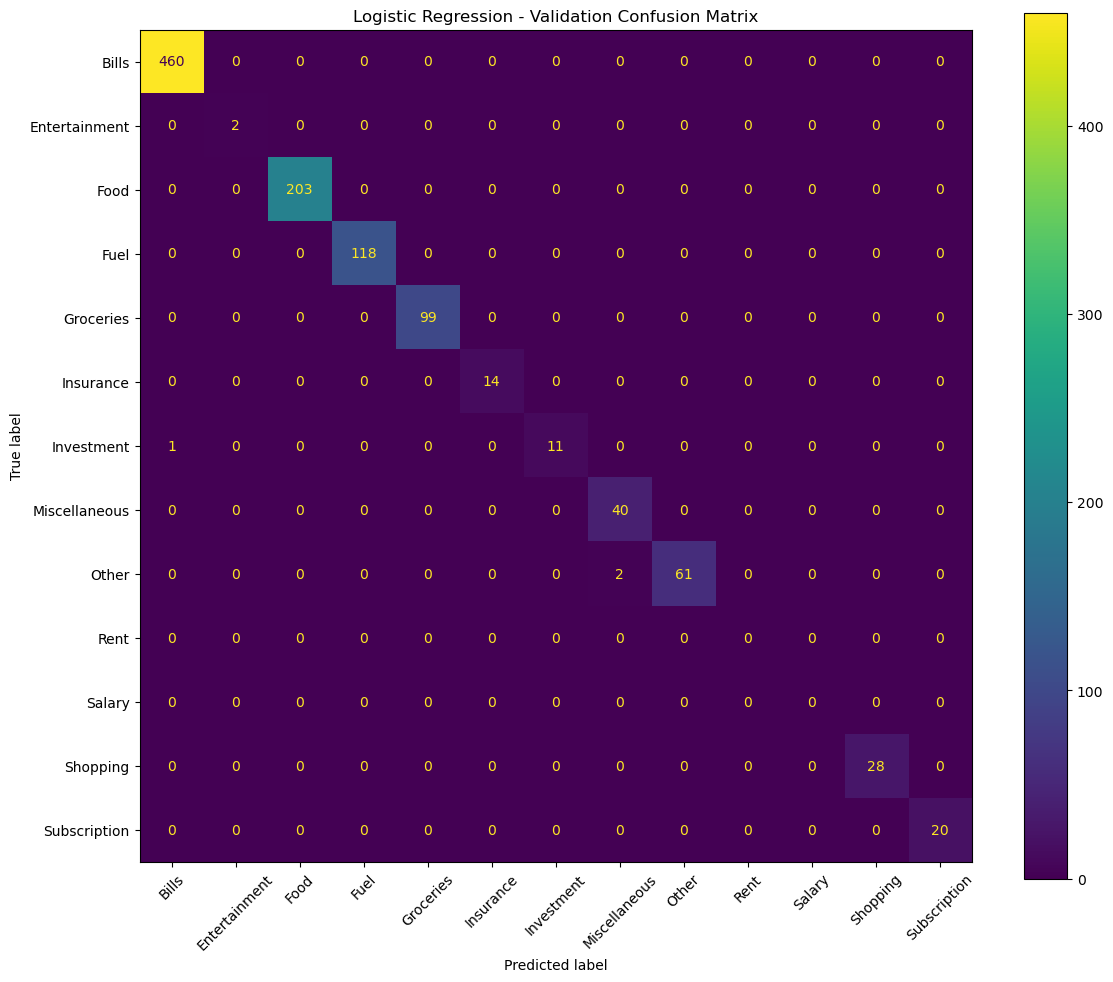

In [573]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val,
    logistic_val_pred,
    labels=logistic_model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=logistic_model.classes_
)

fig, ax = plt.subplots(figsize=(12, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Logistic Regression - Validation Confusion Matrix")
plt.tight_layout()
plt.show()

In [574]:
errors = X_val.copy()

errors["actual"] = y_val.values
errors["predicted"] = logistic_val_pred

errors = errors[
    errors["actual"] != errors["predicted"]
]

print("Total misclassified:", len(errors))

print(
    errors[
        [
            "transaction_text",
            "amount",
            "payment_method",
            "transaction_type",
            "actual",
            "predicted"
        ]
    ].to_string(index=False)
)

Total misclassified: 3
                                      transaction_text  amount payment_method transaction_type     actual     predicted
                    Local Store Debit Card Local Store  207.78     Debit Card            Debit      Other Miscellaneous
                    Local Store Debit Card Local Store  678.52     Debit Card            Debit      Other Miscellaneous
ICICI Prudential MF SIP Investment ICICI Prudential MF 6045.93     Auto Debit            Debit Investment         Bills


In [575]:
train_texts = set(X_train["transaction_text"])
val_texts = set(X_val["transaction_text"])
test_texts = set(X_test["transaction_text"])

print("Train ∩ Validation:", len(train_texts & val_texts))
print("Train ∩ Test:", len(train_texts & test_texts))
print("Validation ∩ Test:", len(val_texts & test_texts))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


#### Validation Accuracy: 99.61%
#### Validation Macro F1: 98.92%

#### Total errors: 4 / 1017

#### Main confusion:
#### Entertainment ↔ Subscription

#### Other categories:
#### No observed misclassification

In [576]:
print(
    model_df["category"].value_counts()
)

category
Bills            2043
Food             1250
Groceries         903
Shopping          462
Other             435
Fuel              423
Miscellaneous     354
Subscription      280
Salary            173
Rent              165
Insurance         150
Entertainment     104
Investment         36
Name: count, dtype: int64


In [577]:
ambiguous_texts = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

ambiguous_texts = ambiguous_texts[
    ambiguous_texts > 1
]

print("Number of ambiguous transaction texts:",
      len(ambiguous_texts))

print("\nAmbiguous transaction texts:")
print(ambiguous_texts)

Number of ambiguous transaction texts: 0

Ambiguous transaction texts:
Series([], Name: category, dtype: int64)


In [578]:
ambiguous_details = (
    model_df[
        model_df["transaction_text"].isin(
            ambiguous_texts.index
        )
    ]
    .sort_values("transaction_text")
)

print(
    ambiguous_details[
        [
            "transaction_text",
            "amount",
            "payment_method",
            "transaction_type",
            "category"
        ]
    ].to_string(index=False)
)

Empty DataFrame
Columns: [transaction_text, amount, payment_method, transaction_type, category]
Index: []


### Error Analysis Result

In [579]:
ambiguous_rows = model_df[
    model_df["transaction_text"].isin(
        ambiguous_texts.index
    )
]

print("Total ambiguous rows:", len(ambiguous_rows))

print(
    ambiguous_rows["category"]
    .value_counts()
)

Total ambiguous rows: 0
Series([], Name: count, dtype: int64)


In [580]:
print(
    ambiguous_rows
    .groupby(["transaction_text", "category"])
    .size()
    .reset_index(name="count")
)

Empty DataFrame
Columns: [transaction_text, category, count]
Index: []


In [581]:
subscription_merchants = [
    "Amazon Prime",
    "Disney+ Hotstar",
    "Netflix"
]

mask = (
    model_df["transaction_text"]
    .str.contains(
        "|".join(subscription_merchants),
        case=False,
        na=False
    )
)

# Only correct rows currently labeled Entertainment
model_df.loc[
    mask & (model_df["category"] == "Entertainment"),
    "category"
] = "Subscription"

In [582]:
print(
    model_df[
        model_df["transaction_text"].str.contains(
            "|".join(subscription_merchants),
            case=False,
            na=False
        )
    ]["category"].value_counts()
)

category
Subscription    93
Name: count, dtype: int64


In [583]:
remaining_ambiguous = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

remaining_ambiguous = remaining_ambiguous[
    remaining_ambiguous > 1
]

print(
    "Remaining ambiguous transaction texts:",
    len(remaining_ambiguous)
)

print(remaining_ambiguous)

Remaining ambiguous transaction texts: 0
Series([], Name: category, dtype: int64)


In [584]:
# performing regex because of disney +

subscription_merchants = [
    "Amazon Prime",
    "Disney+ Hotstar",
    "Netflix"
]

mask = model_df["transaction_text"].apply(
    lambda x: any(
        merchant.lower() in x.lower()
        for merchant in subscription_merchants
    )
)

model_df.loc[
    mask & (model_df["category"] == "Entertainment"),
    "category"
] = "Subscription"

In [585]:
remaining_ambiguous = (
    model_df
    .groupby("transaction_text")["category"]
    .nunique()
)

remaining_ambiguous = remaining_ambiguous[
    remaining_ambiguous > 1
]

print(
    "Remaining ambiguous transaction texts:",
    len(remaining_ambiguous)
)

print(remaining_ambiguous)

Remaining ambiguous transaction texts: 0
Series([], Name: category, dtype: int64)


In [586]:
print(
    model_df["category"].value_counts()
)

category
Bills            2043
Food             1250
Groceries         903
Shopping          462
Other             435
Fuel              423
Miscellaneous     354
Subscription      280
Salary            173
Rent              165
Insurance         150
Entertainment     104
Investment         36
Name: count, dtype: int64


In [587]:
print("Total rows:", len(model_df))
print("Unique transaction texts:",
      model_df["transaction_text"].nunique())

Total rows: 6778
Unique transaction texts: 1209


In [588]:
unique_texts = model_df["transaction_text"].unique()

print("Unique texts:", len(unique_texts))

Unique texts: 1209


In [589]:
from sklearn.model_selection import train_test_split

train_texts, temp_texts = train_test_split(
    unique_texts,
    test_size=0.30,
    random_state=42
)

In [590]:
val_texts, test_texts = train_test_split(
    temp_texts,
    test_size=0.50,
    random_state=42
)

In [591]:
train_mask = model_df["transaction_text"].isin(train_texts)
val_mask = model_df["transaction_text"].isin(val_texts)
test_mask = model_df["transaction_text"].isin(test_texts)

train_df = model_df[train_mask].copy()
val_df = model_df[val_mask].copy()
test_df = model_df[test_mask].copy()

In [592]:
features = [
    "transaction_text",
    "amount",
    "amount_log",
    "payment_method",
    "transaction_type"
]

X_train = train_df[features]
y_train = train_df["category"]

X_val = val_df[features]
y_val = val_df["category"]

X_test = test_df[features]
y_test = test_df["category"]

In [593]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4626, 5)
Validation: (1342, 5)
Test: (810, 5)


In [594]:
train_texts_set = set(X_train["transaction_text"])
val_texts_set = set(X_val["transaction_text"])
test_texts_set = set(X_test["transaction_text"])

print(
    "Train ∩ Validation:",
    len(train_texts_set & val_texts_set)
)

print(
    "Train ∩ Test:",
    len(train_texts_set & test_texts_set)
)

print(
    "Validation ∩ Test:",
    len(val_texts_set & test_texts_set)
)

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [595]:
print("Train categories:")
print(y_train.value_counts())

print("\nValidation categories:")
print(y_val.value_counts())

print("\nTest categories:")
print(y_test.value_counts())

print("\nMissing categories:")

all_categories = set(y.unique())

print(
    "Train:",
    all_categories - set(y_train.unique())
)

print(
    "Validation:",
    all_categories - set(y_val.unique())
)

print(
    "Test:",
    all_categories - set(y_test.unique())
)

Train categories:
category
Bills            1266
Food              864
Groceries         572
Other             340
Shopping          321
Fuel              313
Miscellaneous     247
Subscription      191
Salary            163
Rent              145
Insurance          98
Entertainment      84
Investment         22
Name: count, dtype: int64

Validation categories:
category
Bills            594
Food             217
Groceries        214
Shopping          84
Miscellaneous     71
Other             49
Subscription      33
Fuel              29
Insurance         28
Entertainment     18
Investment         5
Name: count, dtype: int64

Test categories:
category
Bills            183
Food             169
Groceries        117
Fuel              81
Shopping          57
Subscription      56
Other             46
Miscellaneous     36
Insurance         24
Rent              20
Salary            10
Investment         9
Entertainment      2
Name: count, dtype: int64

Missing categories:
Train: set()
Validation:

In [596]:
text_groups = (
    model_df[
        ["transaction_text", "category"]
    ]
    .drop_duplicates()
)

print("Unique text groups:", len(text_groups))

print(
    text_groups["category"].value_counts()
)

Unique text groups: 1209
category
Groceries        350
Food             240
Bills            148
Other            112
Miscellaneous    102
Shopping          79
Subscription      65
Fuel              53
Insurance         24
Entertainment     14
Investment        14
Rent               6
Salary             2
Name: count, dtype: int64


In [597]:
from sklearn.model_selection import GroupShuffleSplit

features = [
    "transaction_text",
    "amount",
    "amount_log",
    "payment_method",
    "transaction_type"
]

X = model_df[features]
y = model_df["category"]

# First split: 70% train, 30% temporary
gss1 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.30,
    random_state=42
)

train_idx, temp_idx = next(
    gss1.split(
        X,
        y,
        groups=model_df["transaction_text"]
    )
)

X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()

X_temp = X.iloc[temp_idx].copy()
y_temp = y.iloc[temp_idx].copy()

In [598]:
gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.50,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(
        X_temp,
        y_temp,
        groups=X_temp["transaction_text"]
    )
)

X_val = X_temp.iloc[val_idx].copy()
y_val = y_temp.iloc[val_idx].copy()

X_test = X_temp.iloc[test_idx].copy()
y_test = y_temp.iloc[test_idx].copy()

In [599]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

train_texts = set(X_train["transaction_text"])
val_texts = set(X_val["transaction_text"])
test_texts = set(X_test["transaction_text"])

print("Train ∩ Validation:", len(train_texts & val_texts))
print("Train ∩ Test:", len(train_texts & test_texts))
print("Validation ∩ Test:", len(val_texts & test_texts))

all_categories = set(y.unique())

print("\nMissing categories:")
print("Train:", all_categories - set(y_train.unique()))
print("Validation:", all_categories - set(y_val.unique()))
print("Test:", all_categories - set(y_test.unique()))

Train: (4590, 5)
Validation: (1059, 5)
Test: (1129, 5)
Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0

Missing categories:
Train: set()
Validation: {'Rent', 'Salary'}
Test: set()


In [600]:
train_texts = set(X_train["transaction_text"])
val_texts = set(X_val["transaction_text"])
test_texts = set(X_test["transaction_text"])

print("Train ∩ Validation:", len(train_texts & val_texts))
print("Train ∩ Test:", len(train_texts & test_texts))
print("Validation ∩ Test:", len(val_texts & test_texts))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [601]:
all_categories = set(y.unique())

print("\nMissing categories:")
print("Train:", all_categories - set(y_train.unique()))
print("Validation:", all_categories - set(y_val.unique()))
print("Test:", all_categories - set(y_test.unique()))


Missing categories:
Train: set()
Validation: {'Rent', 'Salary'}
Test: set()
